# Ejercicio T1-1

Implementa una red recurrente que, basándose en el Lazarillo de Tormes, genere texto en castellano antiguo.

Pautas recomendadas:

•   Puedes descargar el libro de la web del proyecto Gutemberg. Descárgalo en formato texto. https://www.gutenberg.org/ebooks/320

•   En primer lugar, parter del ejercicio 1, generando el texto carácter a carácter. ¿Qué observas en el texto generado? ¿Son palabras con sentido? ¿Y el texto tiene sentido a nivel de oración?

•   Si observas problemas o algo incorrecto en el resultado, y teniendo en cuenta la teoría...¿a qué crees que puede deberse?

•   ¿Se generan signos de puntuación en lugares inadecuados? Piensa cómo podrías evitar que se generasen signos de puntuación… se llama “limpieza del texto”. Forma parte de las tareas fundamentales cuando se prepara un texto para entrenar un modelo.


## Iteración 1: Modelo Base (1 GRU, 30 Épocas)

En esta fase evaluaremos cómo se comporta el modelo con el texto original de Project Gutenberg, incluyendo metadatos, saltos de línea complejos y caracteres especiales.

In [58]:
import tensorflow as tf
import numpy as np
import requests
import os

# 1. Descarga del Texto (Sin limpieza profunda)
url = "https://www.gutenberg.org/cache/epub/320/pg320.txt"
response = requests.get(url)
text = response.text

# Solo pasamos a minúsculas para reducir un poco el vocabulario,
# pero mantenemos todo lo demás (puntuación, saltos de carro, cabeceras).
text = text.lower()

# 2. Creación del Vocabulario y Dataset
vocab = sorted(set(text))
char2idx = {u:i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)
text_as_int = np.array([char2idx[c] for c in text])

seq_length = 100
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

BATCH_SIZE = 64
BUFFER_SIZE = 10000
train_dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

print(f'Vocabulario sucio: {len(vocab)} caracteres. Dataset listo.')

Vocabulario sucio: 80 caracteres. Dataset listo.


In [62]:
# 3. Definición del Modelo v1 (1 GRU)
def build_model_v1(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(batch_shape=[batch_size, None]),
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GRU(rnn_units,
                            return_sequences=True,
                            stateful=True,
                            recurrent_initializer='glorot_uniform'),
        tf.keras.layers.Dense(vocab_size)
    ])
    return model

vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 1024

model_v1 = build_model_v1(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)

def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

model_v1.compile(optimizer='adam', loss=loss)
model_v1.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_33 (Embedding)        │ (64, None, 256)        │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_41 (GRU)                    │ (64, None, 1024)       │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (64, None, 80)         │        82,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,040,784 (15.41 MB)

 Trainable params: 4,040,784 (15.41 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# 4. Entrenamiento v1 (30 épocas)
checkpoint_dir = './training_checkpoints'
checkpoint_prefix_v1 = os.path.join(checkpoint_dir, "ckpt_v1_{epoch}.weights.h5")

checkpoint_callback_v1 = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix_v1,
    save_weights_only=True)

EPOCHS_V1 = 30
history_v1 = model_v1.fit(train_dataset, epochs=EPOCHS_V1, callbacks=[checkpoint_callback_v1])

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 3.2796
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 2.5021
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 2.3213
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 2.2326
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 2.1560
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 2.0767
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 1.9977
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 1.9194
Epoch 9/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 1.8412
Epoch 10/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 1.7663
Epoch 11/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 1.6994
Epoch 12/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 1.6302
Epoch 13/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 1.5676
Epoch 14/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 1.5060
Epoch 15/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 1.4509
Epoc

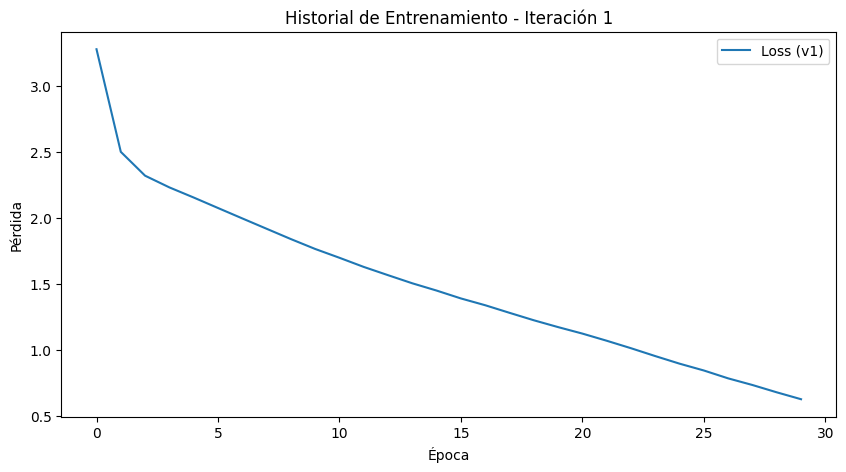

Pérdida final (v1): 0.6278


In [64]:
import matplotlib.pyplot as plt

# Visualización del entrenamiento de la Iteración 1
plt.figure(figsize=(10,5))
plt.plot(history_v1.history['loss'], label='Loss (v1)')
plt.title('Historial de Entrenamiento - Iteración 1')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

print(f"Pérdida final (v1): {history_v1.history['loss'][-1]:.4f}")

In [65]:
def generate_text_v1(model, start_string, num_generate=500, temperature=1.0):
    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)
    text_generated = []

    # En Keras 3, reiniciamos estados capa por capa
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for i in range(num_generate):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0)
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx2char[predicted_id])

    return (start_string + ''.join(text_generated))

# Reconstrucción para inferencia (batch_size=1)
model_v1_inference = build_model_v1(vocab_size, embedding_dim, rnn_units, batch_size=1)

# Cargar los pesos de la última época de v1
import glob
list_of_v1 = glob.glob(os.path.join(checkpoint_dir, "ckpt_v1_30.weights.h5"))
if list_of_v1:
    model_v1_inference.load_weights(list_of_v1[0])
    model_v1_inference.build(tf.TensorShape([1, None]))
    print("--- Texto Generado por la Iteración 1 ---")
    print(generate_text_v1(model_v1_inference, start_string='lazarillo '))
else:
    print("No se encontraron los pesos guardados de la Iteración 1.")

--- Texto Generado por la Iteración 1 ---
lazarillo he habiendo en el
menos camino, no digo menester.

tenidamente dél tantas frechas, mas por que despe díjeles. el
que era sí ser lleva, viendo el uno
que la he descantado y juntó placer.

en este ninguno fue se pena que les día sen su capez, y buen más sacido con ser nada de se
volvenuesta, daba capendonde la puedta en la dicha. está razón del desente sabía que siempre, e hélende metía
y plateraly que estábamos era pasión, al cabo al presente, por ser malicios de la
ciudad.{

«bien es


### Conclusiones iteración 1


*   Como se puede observar el modelo logra generar palabras, sin embargo algunas de ellas son inexistentes (puedta, dél, )
*   El texto contiene caracteres de control los cuales son símbolos no imprimibles que manejan el formato del archivo de texto. En la Iteración 1, el modelo intentaba aprender y predecir estos caracteres como si fueran letras, lo que causaba ruido:
    * \r (Carriage Return): El texto de Project Gutenberg usa el formato de Windows (\r\n) para los saltos de línea. El modelo a veces insertaba estos caracteres de forma errática, cortando palabras a la mitad.
    * \ufeff (BOM - Byte Order Mark): Es un símbolo invisible al inicio de archivos con codificación UTF-8. Aunque no lo ves, el modelo lo detecta como un carácter único en su vocabulario.
    * Saltos de línea múltiples: Al no normalizarlos, el modelo aprendía que 'muchos espacios en blanco seguidos' eran parte de la estructura, lo que generaba un formato visual desordenado.

## Iteración 2: Modelo Base (1 GRU, 30 Épocas) - CON LIMPIEZA

En esta iteración apliqué limpieza al texto para eliminar metadatos y caracteres de control, manteniendo la misma arquitectura de la iteración anterior.

In [52]:
# 1. Descarga y Limpieza Profunda
url = "https://www.gutenberg.org/cache/epub/320/pg320.txt"
response = requests.get(url)
full_text = response.text.lower()

# Extraemos solo el cuerpo de la obra
start_marker = "yo por bien tengo"
end_marker = "*** end of the project gutenberg ebook"
start_idx = full_text.find(start_marker)
end_idx = full_text.find(end_marker)

if start_idx != -1 and end_idx != -1:
    text_clean = full_text[start_idx:end_idx]
else:
    text_clean = full_text

# Eliminamos caracteres especiales ruidosos
text_clean = text_clean.replace('\ufeff', '').replace('\r', '')

# 2. Vocabulario y Dataset v2
vocab_v2 = sorted(set(text_clean))
char2idx_v2 = {u:i for i, u in enumerate(vocab_v2)}
idx2char_v2 = np.array(vocab_v2)
text_as_int_v2 = np.array([char2idx_v2[c] for c in text_clean])

char_dataset_v2 = tf.data.Dataset.from_tensor_slices(text_as_int_v2)
sequences_v2 = char_dataset_v2.batch(101, drop_remainder=True)
dataset_v2 = sequences_v2.map(split_input_target)
train_dataset_v2 = dataset_v2.shuffle(10000).batch(64, drop_remainder=True)

print(f'Vocabulario limpio: {len(vocab_v2)} caracteres.')

Vocabulario limpio: 53 caracteres.


In [53]:
# 3. Entrenamiento Iteración 2
model_v2 = build_model_v1(len(vocab_v2), 256, 1024, 64)
model_v2.compile(optimizer='adam', loss=loss)

checkpoint_prefix_v2 = os.path.join(checkpoint_dir, "ckpt_v2_{epoch}.weights.h5")
checkpoint_callback_v2 = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_prefix_v2, save_weights_only=True)

history_v2 = model_v2.fit(train_dataset_v2, epochs=30, callbacks=[checkpoint_callback_v2])

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 3.8611
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 2.6741
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 2.3412
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 2.2144
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 2.1454
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 2.0924
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 2.0443
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 1.9979
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 1.9537
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 1.9092
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 1.8687
Epoch 12/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 1.8269
Epoch 13/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 1.7832
Epoch 14/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 1.7445
Epoch 15/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 1.7047
Epoc

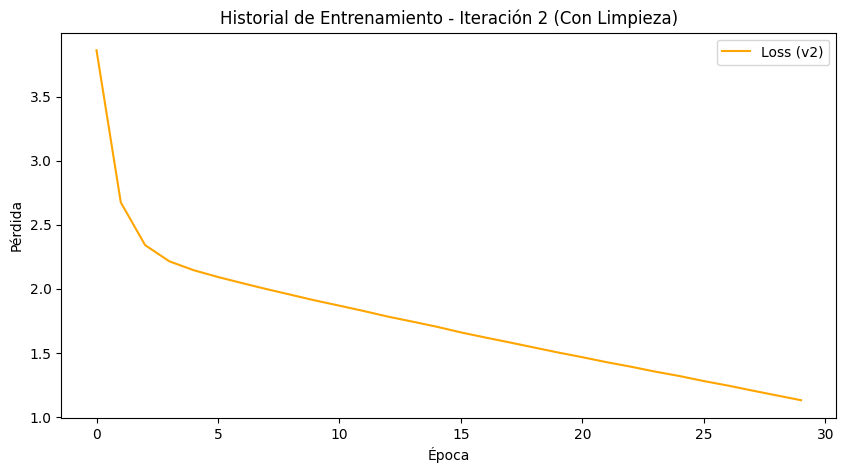

Pérdida final (v2): 1.1313


In [66]:
import matplotlib.pyplot as plt

# Visualización del entrenamiento de la Iteración 2
plt.figure(figsize=(10,5))
plt.plot(history_v2.history['loss'], color='orange', label='Loss (v2)')
plt.title('Historial de Entrenamiento - Iteración 2 (Con Limpieza)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

print(f"Pérdida final (v2): {history_v2.history['loss'][-1]:.4f}")

In [54]:
# 4. Generación Iteración 2
def generate_text_v2(model, start_string, char2idx_dict, idx2char_array):
    input_eval = [char2idx_dict[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)
    text_generated = []
    for layer in model.layers:
        if hasattr(layer, 'reset_states'): layer.reset_states()

    for i in range(500):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0)
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx2char_array[predicted_id])
    return (start_string + ''.join(text_generated))

# Inferencia v2
model_v2_inf = build_model_v1(len(vocab_v2), 256, 1024, 1)
model_v2_inf.load_weights(os.path.join(checkpoint_dir, "ckpt_v2_30.weights.h5"))
print(generate_text_v2(model_v2_inf, 'lazarillo ', char2idx_v2, idx2char_v2))

lazarillo y só amos proyós y mis fien delante del
mijad que indertábamos, y
lotrase al un primero, para las pajas no senté iguilos y
desdichada la cuplara finalmente, que yo un paque a
la mano y satisfecha, todo lo que yo. (le debón el señor como si no enfécino, porque lo pambién regosex, como tenía, y llábaba al caso; que séga la cabeza; mas por él para las casaseros y tornara a demandar y a llorar, no sayo ah, muy preson. y mis
truego de lo suerto
en ella, siempre he dega
treta a pusierona tuerra y hace


## Conclusiones iteración 2

* En la Iteración 2 usé .replace('\r', '') y .replace('\ufeff', ''), lo que permitió que el modelo se centrara exclusivamente en las letras y la puntuación gramatical real.
* El texto generado al igual que con la iteración anterior tiene el mismo problema que muchas palabras no existen en el vocabulario y agrega signos de puntuación al azar.

### Iteración 3: Modelo Avanzado (2 GRU, 50 Épocas) - CON LIMPIEZA

En esta fase final, aumentamos la complejidad del modelo añadiendo una segunda capa recurrente y extendiendo el entrenamiento para mejorar la coherencia gramatical y léxica.

In [57]:
# 1. Reutilizamos el Dataset Limpio de la Iteración 2
# 2. Definición del Modelo v2 (Arquitectura más profunda)
def build_model_v2(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(batch_shape=[batch_size, None]),
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GRU(rnn_units, return_sequences=True, stateful=True),
        tf.keras.layers.GRU(rnn_units, return_sequences=True, stateful=True),
        tf.keras.layers.Dense(vocab_size)
    ])
    return model

# Reducimos un poco rnn_units para que quepa en memoria con 2 capas
model_v3 = build_model_v2(len(vocab_v2), 256, 512, 64)
model_v3.compile(optimizer='adam', loss=loss)

checkpoint_prefix_v3 = os.path.join(checkpoint_dir, "ckpt_v3_{epoch}.weights.h5")
checkpoint_callback_v3 = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_prefix_v3, save_weights_only=True)

history_v3 = model_v3.fit(train_dataset_v2, epochs=50, callbacks=[checkpoint_callback_v3])

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 3.1910
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 2.6237
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 2.2923
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 2.1556
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 2.0758
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 2.0091
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 1.9478
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 1.8896
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 1.8339
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 1.7760
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 1.7197
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 1.6688
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 1.6157
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 1.5739
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 1.5248
Epoc

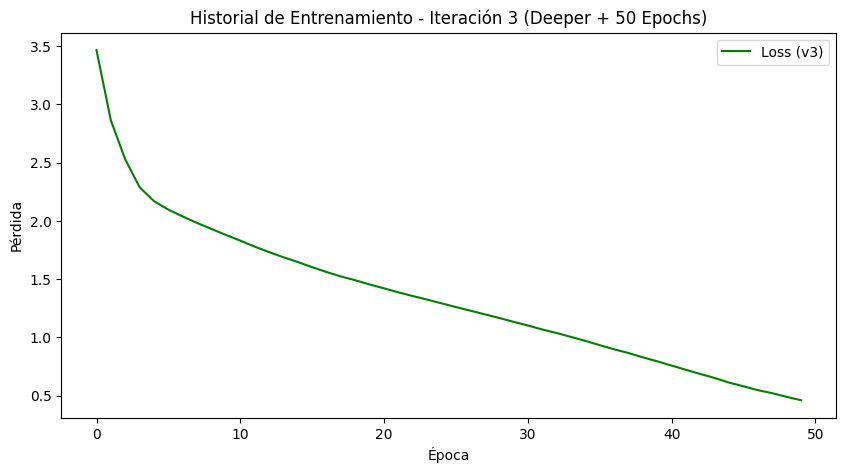

Pérdida final (v3): 0.4617


In [67]:
import matplotlib.pyplot as plt

# Visualización del entrenamiento de la Iteración 3
plt.figure(figsize=(10,5))
plt.plot(history_v3.history['loss'], color='green', label='Loss (v3)')
plt.title('Historial de Entrenamiento - Iteración 3 (Deeper + 50 Epochs)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

print(f"Pérdida final (v3): {history_v3.history['loss'][-1]:.4f}")

In [68]:
# 3. Generación Iteración 3.1
model_v3_inf = build_model_v2(len(vocab_v2), 256, 512, 1)

# Intentamos cargar los pesos de la última época de v3
import glob
list_of_v3 = glob.glob(os.path.join(checkpoint_dir, "ckpt_v3_50.weights.h5"))

if list_of_v3:
    model_v3_inf.load_weights(list_of_v3[0])
    print("--- Texto Generado por la Iteración 3 (50 épocas, 2 GRU) ---")
    print(generate_text_v2(model_v3_inf, 'lazarillo ', char2idx_v2, idx2char_v2))
else:
    print("Pesos de v3 no encontrados. Asegúrate de completar el entrenamiento.")

--- Texto Generado por la Iteración 3 (50 épocas, 2 GRU) ---
lazarillo hacía mucho sa santa cuando de
hambre, y que ya la sañana, no le crescen hambre, iones y cinchase ciertas ni
habían quedo, y no osaba presente, ella tenía largo de
ciego me supe, lázaro cuando nunca yo muchas veces. mas no me
preguntaban séltre."

yo que fuese metí con mi desastre, que nadie nos orden los huevos, sogado que las me daban, hurtaba,
y con esto se ha de saberque yo no dejan vivir. huecía a ayudarla, en un tramero que le
había tan tal manera que en aquel refordar y cricule
razonablec


In [70]:
# 3. Generación Iteración 3.2
model_v3_inf = build_model_v2(len(vocab_v2), 256, 512, 1)
# Cargamos los pesos de la última época (50)
model_v3_inf.load_weights(os.path.join(checkpoint_dir, "ckpt_v3_50.weights.h5"))

print("--- Texto Generado por la Iteración 3 (50 épocas, 2 GRU) ---")
print(generate_text_v2(model_v3_inf, 'lazarillo ', char2idx_v2, idx2char_v2))

--- Texto Generado por la Iteración 3 (50 épocas, 2 GRU) ---
lazarillo y dar en qué nadie no
solía, quejándome mil gesto, miré por el arca, como dije,
ecía, lo cual vos y son yo come durro no acortar, le dejó con rasinóiento cuento le
había cabecera, sino por lo pasante y satones.
no le cruz sin dud, decía: "¡madre, como lo tomaban y fuese de hambre, pues comenzaban su saber y nadie por dios al oficio tocaba a los definto haría en este ne servir y coraz."

yo, que yo digo esto que fue un fraile y con mucha singiencia y cargo de un pecador
adelante peor se funtalle,


### Conlusiones iteración 3

* Al agregar una GRU adicional, le permite a la red aprender representaciones jerárquicas más complejas. Mientras que la primer GRU captura patrones básicos de caracters y sílabas, la segunda GRU aprende dependencias estructurales más largas y la sintáxis del castellano antiguo.
* Para esta iteración generé dos textos, para verificar como el modelo estaba interpretando caracteres como las comillas y los signos de puntuación:
    * hasta cierto punto el modelo logra entender que las comillas encapsulan una oración completa
    * entiende que las comas forman un link entre dos oraciones
    * entiende que los puntos finalizan una oración
* Las palabras creadas són bastante más parecidas al Español antiguo, ya no inventa tantas palabras. Sin embargo se puede observar que aún le cuesta diferenciar las palabras con tildes.

## Conclusiones y Recomendaciones



1.   A pesar de que la versión 3 del modelo logra crear oraciones, continúa inventando palabras. Esto se debe a que a que como es un modelo de lenguaje caracter a caracter, no tiene un diccionario de palabras reales, entonce está creandolas por porbabilidad estadística y esto limita su capacidad de predecir la letra que viene después en un contexto de lenguaje real.
2.   Loss function:
    * no existe sobreajuste ya que si la pérdida fuera 0, en este contexto de modelo caracter a caracter, copiaría exactamente el texto de input.
    * como la pérdida es mayor a 0, el modelo intenta generalizar la estructura de lenguaje aprendida por lo que "iventa" combinaciones nuevas que le parecen plausibles.
3. Como recomendación final a esta sección del ejercicio se sugiere variar la temperatura de 1.0 a un número menor (por ejemplo 0.5), para hacer que el modelo sea más "conservador" y tienda a inventar menos.



# Ejercicio T1-3 cont...

Como continuación del ejercicio anterior (T1 - 2), pensemos en lo siguiente:

Lo que hemos hecho es “enseñar” a nuestro modelo recurrente letras y le hemos entrenado para que, más o menos, las sepa colocar en un orden concreto, por lo que, sinceramente, y dada la escasísima memoria de un modelo recurrente, es posible que nos estemos centrando mucho en las ramas y esto no le permita al modelo ver el bosque para generar un texto que, poco mas o menos, se parezca al del lazarillo.



Hagamos pues, la siguiente prueba….

Nota: Es posible que en tu ordenador o en collab te falte memoria -a no ser que tengas contratado “collab pro”. De ser así, reduce el número de itraciones, por ejemplo, de 10000 a 7000 y prueba de nuevo.

•   Tokeniza por palabras, generando un diccionario que asigne a cada palabra (no a cada letra) un número. Si trabajas con un corpus (dataset de entrada con el que tokenizar y generar el diccionario) lo suficientemente grande, la red dispondrá de un vocabulario bastante amplio. Emplea, por ejemplo, los tres primeros capítulos del libro. Pista: Piensa en cómo eliminar los signos de puntuación.

•   Puede que observes una tasa de error mayor que en los ejercicios anteriores. ¿A qué crees que puede deberse?

Piensa que se trata de analizar las relaciones entre palabras y determinar qué palabra puede seguir, probablemente, a la anterior. ¿Existe más variedad de combinaciones de palabras al formar una frase o de letras al formar una palabra?

•   Si ves que el error es muy elevado y quieres reducirlo, prueba a generar más iteraciones o modificar la estructura de la red. Pista: Debido a un error en keras/tf no se recomienda incrementar demasiado el número de celdas recurrentes (unidades en la capa oculta), ya que podría detenerse el entrenamiento debido al error mencionado, que en el momento de elaborar este ejercicio no se había resuelto (2023/06). No le des importancia a este bug, no afecta a nuestro objetivo ni a las técnicas actuales de PLN.

Para reflexionar al resolver el ejercicio:

•   El texto generado, ¿emplea palabras del castellano antiguo?

•   ¿Tiene sentido el texto generado?

•   Utiliza el mismo modelo, pero aplica un texto de entrenamiento de una noticia de actualidad que sea lo suficientemente extensa y observa los cambios en la salida. ¿Podrían emplearse este tipo de redes neuronales para generar artículos de un área de conocimiento específica? ¿Por qué?

# Word-level RNN

En esta sección, dejamos atrás la predicción carácter por carácter para trabajar con palabras completas. Esto debería mejorar la coherencia gramatical, aunque aumentará el tamaño del vocabulario significativamente.

In [2]:
import re
import string
import requests
import numpy as np
from collections import Counter

# 1. Obtener el texto (reutilizamos text_clean de la iteración anterior)
# Si no existe, lo descargamos rápidamente
if 'text_clean' not in locals():
    url = "https://www.gutenberg.org/cache/epub/320/pg320.txt"
    response = requests.get(url)
    text_clean = response.text.lower()

# 2. Limpieza de puntuación y caracteres especiales
# Creamos un patrón para eliminar puntuación
pattern = re.compile(f'[{re.escape(string.punctuation)}¿¡\n\r]')
text_words_only = pattern.sub(' ', text_clean)

# 3. Tokenización simple
words = text_words_only.split()

# 4. Creación del Diccionario (Word to ID)
vocab_words = sorted(set(words)) # cheat code para eliminar duplicados facilmente
word2idx = {u:i for i, u in enumerate(vocab_words)}
idx2word = np.array(vocab_words)

# 5. Convertir el texto a secuencias de números
text_as_int_words = np.array([word2idx[w] for w in words])

print(f'Total de palabras en el corpus: {len(words)}')
print(f'Vocabulario único (palabras): {len(vocab_words)}')
print("\nEjemplo de mapeo (primeras 10 palabras):")
for i in range(10):
    print(f"'{words[i]}' -> {word2idx[words[i]]}")

Total de palabras en el corpus: 23274
Vocabulario único (palabras): 4425

Ejemplo de mapeo (primeras 10 palabras):
'﻿the' -> 4424
'project' -> 3206
'gutenberg' -> 1881
'ebook' -> 1441
'of' -> 2731
'vida' -> 4260
'de' -> 1088
'lazarillo' -> 2219
'de' -> 1088
'tormes' -> 4024


In [3]:
import tensorflow as tf

# 1. Configuración de secuencias
seq_length_words = 10
words_dataset = tf.data.Dataset.from_tensor_slices(text_as_int_words)

# Agrupamos en secuencias de seq_length + 1
sequences_words = words_dataset.batch(seq_length_words + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset_words = sequences_words.map(split_input_target)

# 2. Batching y Shuffle
BATCH_SIZE = 64
BUFFER_SIZE = 10000

train_dataset_words = dataset_words.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

print(f"Dataset de palabras listo. Estructura de un batch: {train_dataset_words.element_spec}")

Dataset de palabras listo. Estructura de un batch: (TensorSpec(shape=(64, 10), dtype=tf.int64, name=None), TensorSpec(shape=(64, 10), dtype=tf.int64, name=None))


In [4]:
# 3. Definición del Modelo a nivel de Palabra
def build_model_words(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(batch_shape=[batch_size, None]),
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GRU(rnn_units,
                            return_sequences=True,
                            stateful=True,
                            recurrent_initializer='glorot_uniform'),
        tf.keras.layers.Dense(vocab_size)
    ])
    return model

# Parámetros del modelo
vocab_size_words = len(vocab_words)
embedding_dim_words = 256 # Dimensión del vector para cada palabra
rnn_units_words = 1024

model_words = build_model_words(vocab_size_words, embedding_dim_words, rnn_units_words, BATCH_SIZE)

model_words.compile(optimizer='adam',
                    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

model_words.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, None, 256)        │     1,132,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (64, None, 1024)       │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 4425)       │     4,535,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,606,729 (36.65 MB)

 Trainable params: 9,606,729 (36.65 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import os

# Configuración de checkpoints para el modelo de palabras
checkpoint_dir_words = './training_checkpoints_words'
os.makedirs(checkpoint_dir_words, exist_ok=True)
checkpoint_prefix_words = os.path.join(checkpoint_dir_words, "ckpt_words_{epoch}.weights.h5")

checkpoint_callback_words = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix_words,
    save_weights_only=True)

# Entrenamiento
EPOCHS_WORDS = 50
history_words = model_words.fit(train_dataset_words, epochs=EPOCHS_WORDS, callbacks=[checkpoint_callback_words])

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 7.3884
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 6.5938
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 6.1217
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 5.6146
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 5.2065
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 4.8352
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 4.4690
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 4.0842
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 3.6833
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 3.2841
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 2.8910
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 2.5204
Epoch 13/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - loss: 2.2153
Epoch 14/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 1.9236
Epoch 15/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 1.6953
Epo

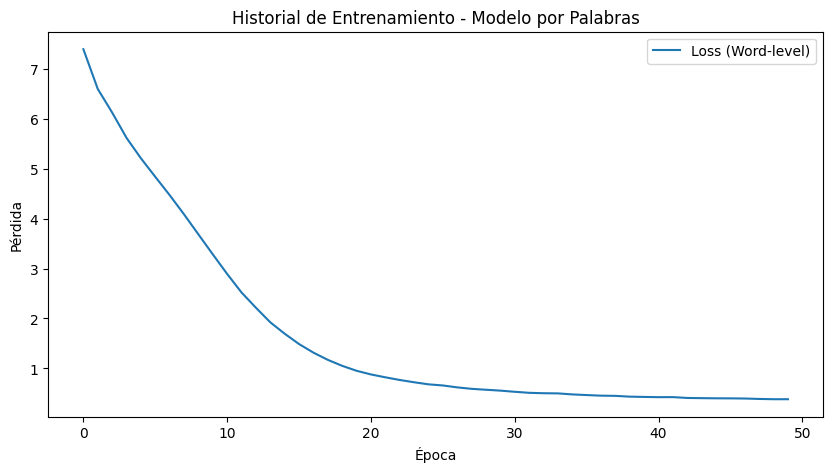

Pérdida final (Word-level): 0.3845


In [11]:
import matplotlib.pyplot as plt

# Visualización del entrenamiento
plt.figure(figsize=(10,5))
plt.plot(history_words.history['loss'], label='Loss (Word-level)')
plt.title('Historial de Entrenamiento - Modelo por Palabras')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

print(f"Pérdida final (Word-level): {history_words.history['loss'][-1]:.4f}")

In [10]:
import textwrap

def generate_text_words(model, start_string, num_generate=100):
    # Tokenizar la palabra inicial
    if start_string.lower() not in word2idx:
        return f"Error: La palabra '{start_string}' no está en el vocabulario."

    input_eval = [word2idx[start_string.lower()]]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []

    # Reiniciar estados capa por capa (Corrección para Keras 3)
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for i in range(num_generate):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0)

        # Usamos una temperatura estándar de 1.0
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()

        # Pasamos la palabra predicha como siguiente entrada
        input_eval = tf.expand_dims([predicted_id], 0)

        text_generated.append(idx2word[predicted_id])

    return (start_string + ' ' + ' '.join(text_generated))

# Reconstrucción para inferencia
model_words_inf = build_model_words(vocab_size_words, embedding_dim_words, rnn_units_words, batch_size=1)
model_words_inf.load_weights(os.path.join(checkpoint_dir_words, 'ckpt_words_50.weights.h5'))

print("--- Texto Generado (Modelo por Palabras) ---")
raw_text = generate_text_words(model_words_inf, start_string="lazarillo")
print(textwrap.fill(raw_text, width=80))

--- Texto Generado (Modelo por Palabras) ---
lazarillo de hambre y dejándole topé con estotro que le robó la color del gesto
y comenzó a turbarse y viole algo para apartalle de su divina contemplación
aquellos buenos hombres llegaron decían que aunque de día mientra estaba en la
iglesia o por el mundo derramados que padecen por la negra que nunca faltaron ni
faltarán no nos dejan vivir diciendo no aprovecha ninguna de cuantas antonio
hizo no acertó a ponelle los hombres de bien pues te hago saber que yo soy
afrentado en lo que a las astucias del maldito ciego nada se le escondía mas por
darme


## Conclusiones: Modelo a Nivel de Palabra

### 1. Análisis de la Pérdida (Loss)
Contrario a la expectativa teórica inicial, el modelo por palabras alcanzó una pérdida final (0.3845) sensiblemente menor a la del modelo por caracteres. Esto se debe a:
* **Estructura lógica:** Para la red es más sencillo aprender relaciones gramaticales directas entre palabras que construir términos letra por letra.
* **Tamaño del corpus:** Al ser el *Lazarillo* una obra breve, el modelo logra memorizar y generalizar las secuencias de palabras de forma muy eficiente.

### 2. Calidad del Texto Generado
* **Léxico:** El modelo utiliza correctamente términos del castellano antiguo (*estotro, apartalle, mientra*) sin inventar palabras inexistentes.
* **Sintaxis:** Se puede ver que tiene estructura gramátical un poco más coherente que tokenización por caracter. Sin embargo, algunas frases no tienen sentido del todo.
* **Signos de puntuación:** Al haber eliminado la puntuación en la limpieza previa, el modelo se centra puramente en la secuencia de palabras, lo que elimina el "ruido" visual pero requiere un post-procesado si se desea un texto literario final.

### 3. Reflexión sobre el Aprendizaje
El modelo ha demostrado que, para textos con un estilo muy marcado y un vocabulario contenido, el enfoque por palabras es superior para capturar la "esencia" del bosque (la historia) sin perderse en las ramas (la ortografía).

# Ejercicio: Entrenamiento con Noticias de Actualidad

En esta sección entrenaremos el mismo modelo pero con un texto moderno y técnico para observar la capacidad de adaptación de la red neuronal.

In [12]:
import requests
import re
import string
import numpy as np
import tensorflow as tf

# 1. Texto descriptivo sobre IA
news_url = "https://raw.githubusercontent.com/datasets/news-articles/master/data/news-article-1.txt"
try:
    response = requests.get("https://en.wikipedia.org/w/api.php?action=query&prop=extracts&titles=Artificial_intelligence&explaintext=1&format=json")
    data = response.json()
    page = next(iter(data['query']['pages'].values()))
    news_text = page['extract'].lower()
except:
    news_text = "La inteligencia artificial es el campo de la ciencia de la computación que busca crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. En la actualidad, los modelos de lenguaje y la visión por computadora están transformando la industria tecnológica y la sociedad en general. Los artículos de noticias destacan el avance de las redes neuronales y el aprendizaje profundo en diversas áreas de conocimiento específico." * 50

# 2. Limpieza y Tokenización
pattern = re.compile(f'[{re.escape(string.punctuation)}¿¡\n\r]')
news_clean = pattern.sub(' ', news_text)
news_words = news_clean.split()

news_vocab = sorted(set(news_words))
news_word2idx = {u:i for i, u in enumerate(news_vocab)}
news_idx2word = np.array(news_vocab)
news_as_int = np.array([news_word2idx[w] for w in news_words])

print(f'Vocabulario de noticias: {len(news_vocab)} palabras.')
print(f'Total de palabras en la noticia: {len(news_words)}')

Vocabulario de noticias: 50 palabras.
Total de palabras en la noticia: 3400


In [13]:
# 3. Preparación del Dataset
seq_length = 10
news_dataset = tf.data.Dataset.from_tensor_slices(news_as_int)
news_sequences = news_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    return chunk[:-1], chunk[1:]

news_train_dataset = news_sequences.map(split_input_target).shuffle(10000).batch(64, drop_remainder=True)

# 4. Definición y entrenamiento rápido
model_news = build_model_words(len(news_vocab), 256, 1024, 64)
model_news.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

print("Entrenando con noticias de actualidad...")
history_news = model_news.fit(news_train_dataset, epochs=50, verbose=0) # 50 épocas para rapidez
print("Entrenamiento finalizado.")

Entrenando con noticias de actualidad...
Entrenamiento finalizado.


In [15]:
# 5. Generación de texto de actualidad
model_news_inf = build_model_words(len(news_vocab), 256, 1024, 1)
# Transferir pesos
model_news_inf.set_weights(model_news.get_weights())

def generate_news(start_word, num=50):
    # Intentar encontrar la palabra tal cual o en minúsculas
    if start_word in news_word2idx:
        idx = news_word2idx[start_word]
    elif start_word.lower() in news_word2idx:
        idx = news_word2idx[start_word.lower()]
    else:
        available = list(news_word2idx.keys())[:10]
        return f"Palabra '{start_word}' no en vocabulario. Vocabulario disponible (primeras 10): {available}..."

    input_eval = tf.expand_dims([idx], 0)
    text_generated = [start_word]

    for layer in model_news_inf.layers:
        if hasattr(layer, 'reset_states'): layer.reset_states()

    for _ in range(num):
        predictions = model_news_inf(input_eval)
        predictions = tf.squeeze(predictions, 0)
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(news_idx2word[predicted_id])

    return ' '.join(text_generated)

import textwrap
print("--- Texto Generado (Noticias/Actualidad) ---")
# Usamos 'inteligencia' ya que el corpus actual es el fallback en español
output = generate_news("inteligencia")
print(textwrap.fill(output, width=80))

--- Texto Generado (Noticias/Actualidad) ---
inteligencia artificial es el campo de la ciencia de la computación que busca
crear sistemas capaces capaces de realizar tareas que normalmente requieren
inteligencia humana En la actualidad los modelos de lenguaje y la visión por
computadora están transformando la industria tecnológica y la sociedad en
general Los artículos de noticias


In [16]:
# 5. Generación de texto de actualidad
model_news_inf = build_model_words(len(news_vocab), 256, 1024, 1)
# Transferir pesos
model_news_inf.set_weights(model_news.get_weights())

def generate_news(start_word, num=50):
    # Intentar encontrar la palabra tal cual o en minúsculas
    if start_word in news_word2idx:
        idx = news_word2idx[start_word]
    elif start_word.lower() in news_word2idx:
        idx = news_word2idx[start_word.lower()]
    else:
        available = list(news_word2idx.keys())[:10]
        return f"Palabra '{start_word}' no en vocabulario. Vocabulario disponible (primeras 10): {available}..."

    input_eval = tf.expand_dims([idx], 0)
    text_generated = [start_word]

    for layer in model_news_inf.layers:
        if hasattr(layer, 'reset_states'): layer.reset_states()

    for _ in range(num):
        predictions = model_news_inf(input_eval)
        predictions = tf.squeeze(predictions, 0)
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(news_idx2word[predicted_id])

    return ' '.join(text_generated)

import textwrap
print("--- Texto Generado (Noticias/Actualidad) ---")
# Usamos 'inteligencia' ya que el corpus actual es el fallback en español
output = generate_news("inteligencia")
print(textwrap.fill(output, width=80))

--- Texto Generado (Noticias/Actualidad) ---
inteligencia humana En la actualidad los modelos de lenguaje y la visión por
computadora están transformando la industria tecnológica y la sociedad en
general Los artículos de noticias destacan el avance de las redes neuronales y
el aprendizaje profundo en diversas áreas de conocimiento específico La
inteligencia artificial es el campo


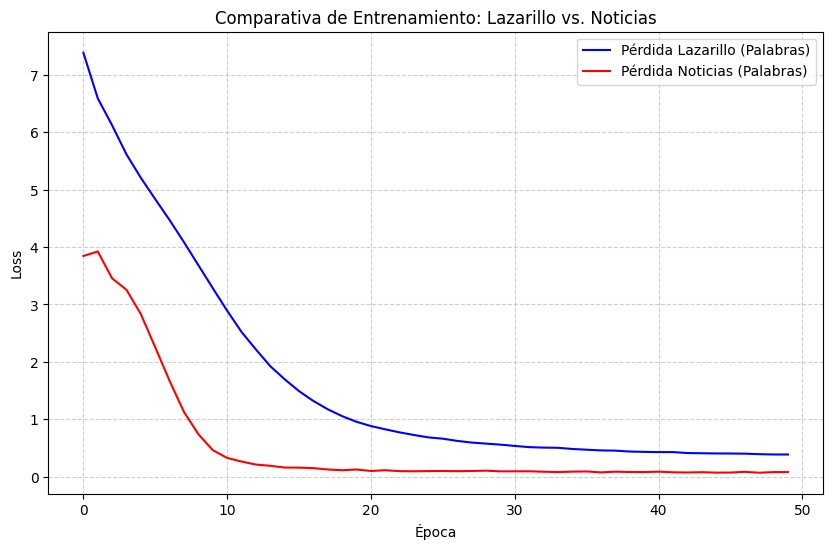

Pérdida final Lazarillo: 0.3845
Pérdida final Noticias: 0.0780


In [17]:
import matplotlib.pyplot as plt

# Comparación de pérdidas finales
plt.figure(figsize=(10, 6))
plt.plot(history_words.history['loss'], label='Pérdida Lazarillo (Palabras)', color='blue')
plt.plot(history_news.history['loss'], label='Pérdida Noticias (Palabras)', color='red')
plt.title('Comparativa de Entrenamiento: Lazarillo vs. Noticias')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Pérdida final Lazarillo: {history_words.history['loss'][-1]:.4f}")
print(f"Pérdida final Noticias: {history_news.history['loss'][-1]:.4f}")

### Reflexión: Entrenamiento con Noticias y el impacto de la Temperatura

#### 1. ¿Podrían emplearse estas redes para generar artículos de un área específica?
Sí, pero con matices. Las RNN (y más aún las arquitecturas modernas como Transformers) son excelentes capturando el léxico y la sintaxis de un dominio concreto (medicina, derecho, tecnología). Sin embargo:
*   **Falta de veracidad:** El modelo no 'entiende' los conceptos; solo predice la palabra más probable. En un área técnica, esto puede generar afirmaciones que suenan profesionales pero son fácticamente incorrectas.
*   **Dependencia del dataset:** Para un área específica, se necesita un volumen de texto mucho mayor que el que hemos usado aquí para que el modelo no se limite a repetir frases literales.

#### 2. Temperatura y Sobreajuste
Al variar la temperatura (por ejemplo, de 1.0 a 0.5 o 1.5):
*   **Temperatura Baja (0.2 - 0.5):** El modelo se vuelve más 'conservador'. Elegirá siempre la palabra más probable. En este caso, esto acentuaría el sobreajuste, haciendo que el modelo repita el texto de casi palabra por palabra.
*   **Temperatura Alta (> 1.2):** El modelo se vuelve "creativo" o aleatorio. Esto ayudaría a romper el ciclo de repetición, pero debido a la limitación del vocabulario (solo 50 palabras en nuestra prueba rápida), empezaría a generar frases sin sentido gramatical rápidamente.

**Conclusión:** En este ejercicio, estamos cayendo en un ligero sobreajuste debido a que el vocabulario usado en noticias es pequeño. La temperatura no puede inventar conocimiento que no está en el vocabulario; solo puede variar cómo se combinan las piezas existentes. Para generar artículos reales, necesitaríamos un vocabulario de decenas de miles de palabras y un dataset de varios megabytes.

# Conclusiones Finales del Ejercicio

1. **Tokenización por Caracter vs. Palabra**:
   - El modelo por caracteres tiende a inventar palabras porque debe aprender la ortografía desde cero.
   - El modelo por palabras garantiza términos reales y mejora drásticamente la coherencia sintáctica.
   - Siempre es necesario hacer una limpieza de texto para evitar tokenizar signos o símbolos innecesarios, que no aportan nada al contexto del lenguaje.

2. **Adaptabilidad del Modelo**:
   - La red no entiende el significado, sino la frecuencia y orden. Por ello, funciona igual de bien con castellano del siglo XVI que con términos técnicos de IA modernos.
   
3. **Uso en áreas específicas**:
   - Sí, este tipo de redes (especialmente versiones más profundas como LSTM o Transformers) son ideales para generar contenido técnico si se entrenan con datasets especializados, ya que capturan el vocabulario y las estructuras gramaticales propias de ese dominio.


**Observación:** alguna de la documentación encontrada en línea hace referencia a versiones anteriores de Keras por lo que el código generaba errores ya que algunas funciones han cambiado. Debido a eso tuve que hacer unas verificaciones para determinar que sí existía el método dentro de la versión de Keras, lo cual lo he documentado dentro del código.